# Sentiment Analysis on Product Reviews


---
## Setup & Imports

In [1]:
!pip install textblob --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')



## Task 1 — Data Loading & Exploration

In [3]:
df = pd.read_csv(r"C:\Users\abhin\Downloads\project1\Reviews.csv",nrows=5000)
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [4]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print('\nColumn names:')
for col in df.columns:
    print(f'  - {col}')

Rows    : 4999
Columns : 10

Column names:
  - Id
  - ProductId
  - UserId
  - ProfileName
  - HelpfulnessNumerator
  - HelpfulnessDenominator
  - Score
  - Time
  - Summary
  - Text


In [5]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      4999 non-null   int64 
 1   ProductId               4999 non-null   object
 2   UserId                  4999 non-null   object
 3   ProfileName             4999 non-null   object
 4   HelpfulnessNumerator    4999 non-null   int64 
 5   HelpfulnessDenominator  4999 non-null   int64 
 6   Score                   4999 non-null   int64 
 7   Time                    4999 non-null   int64 
 8   Summary                 4999 non-null   object
 9   Text                    4999 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.7+ KB


In [6]:
print('Review text column: Text')
print('Sample review:')
print(df['Text'].iloc[0])
print('\nRating column: Score')
print(df['Score'].value_counts().sort_index())

Review text column: Text
Sample review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Rating column: Score
Score
1     469
2     290
3     395
4     712
5    3133
Name: count, dtype: int64



## Task 2 — Data Cleaning

In [7]:
print(f'Before cleaning: {df.shape[0]} rows')
df = df[['Text', 'Score']].copy()
df.dropna(subset=['Text'], inplace=True)
df = df[df['Text'].str.strip() != '']

print(f'After removing nulls: {df.shape[0]} rows')
before = df.shape[0]
df.drop_duplicates(subset=['Text'], inplace=True)
print(f'Removed {before - df.shape[0]} duplicates')
df.reset_index(drop=True, inplace=True)
print(f'After cleaning: {df.shape[0]} rows')
df.head(3)

Before cleaning: 4999 rows
After removing nulls: 4999 rows
Removed 16 duplicates
After cleaning: 4983 rows


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4


In [8]:
print('Null check after cleaning:')
print(df.isnull().sum())


Null check after cleaning:
Text     0
Score    0
dtype: int64


## Task 3 — Sentiment Analysis using TextBlob

In [9]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def label_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

print('Running sentiment analysis... (may take ~30 seconds)')
df['Polarity']  = df['Text'].apply(get_polarity)
df['Sentiment'] = df['Polarity'].apply(label_sentiment)
print('Sentiment analysis complete!')

Running sentiment analysis... (may take ~30 seconds)
Sentiment analysis complete!


In [10]:
print('Sample output:')
df[['Text', 'Score', 'Polarity', 'Sentiment']].head(10)

Sample output:


,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive
5,I got a wild hair for taffy and ordered this f...,4,0.257407,Positive
6,This saltwater taffy had great flavors and was...,5,0.250833,Positive
7,This taffy is so good. It is very soft and ch...,5,0.486000,Positive
8,Right now I'm mostly just sprouting this so my...,5,0.428571,Positive
9,This is a very healthy dog food. Good for thei...,5,0.450000,Positive


In [11]:
sentiment_counts = df['Sentiment'].value_counts()
total = len(df)
print('Sentiment Distribution:')
print('-' * 35)
for s, c in sentiment_counts.items():
    pct = c / total * 100
    print(f'  {s:<10} {c:>4} ({pct:5.1f}%)')
print('-' * 35)
print(f'  {"TOTAL":<10} {total:>4}')

Sentiment Distribution:
-----------------------------------
  Positive   4402 ( 88.3%)
  Negative    501 ( 10.1%)
  Neutral      80 (  1.6%)
-----------------------------------
  TOTAL      4983



## Task 4 — Visualizations
### Chart 1: Bar Chart

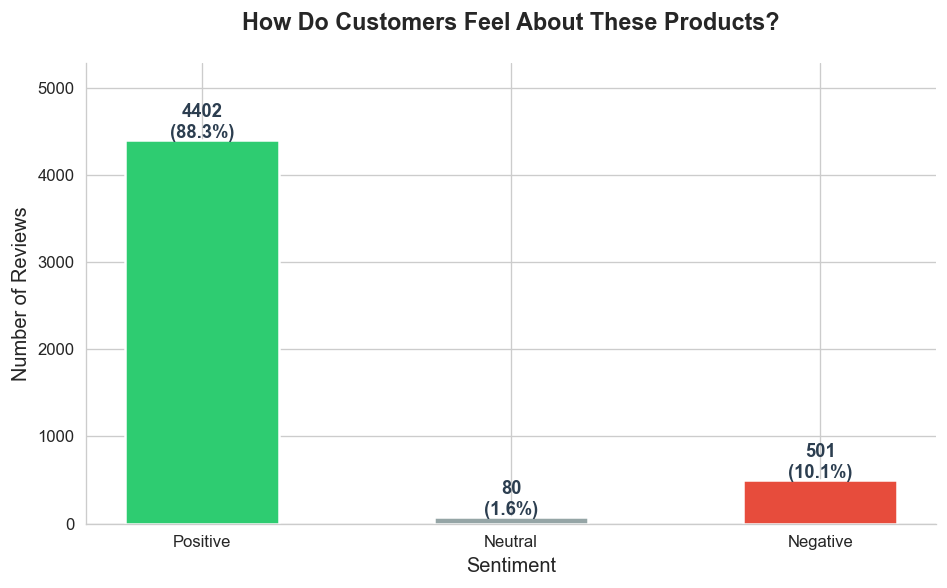

In [12]:
sentiment_counts = df['Sentiment'].value_counts()
total = len(df)
sentiment_order  = ['Positive', 'Neutral', 'Negative']
sentiment_values = [sentiment_counts.get(s, 0) for s in sentiment_order]
bar_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    sentiment_order,
    sentiment_values,
    color=bar_colors,
    width=0.5,
    edgecolor='white',
    linewidth=1.5
)

for bar, value in zip(bars, sentiment_values):
    percentage = value / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 20,              
        f'{value}\n({percentage:.1f}%)',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='#2c3e50'
        )

ax.set_title('How Do Customers Feel About These Products?', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)

ax.set_ylim(0, max(sentiment_values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_bar.png', bbox_inches='tight', dpi=150)
plt.show()

### Chart 2: Pie Chart

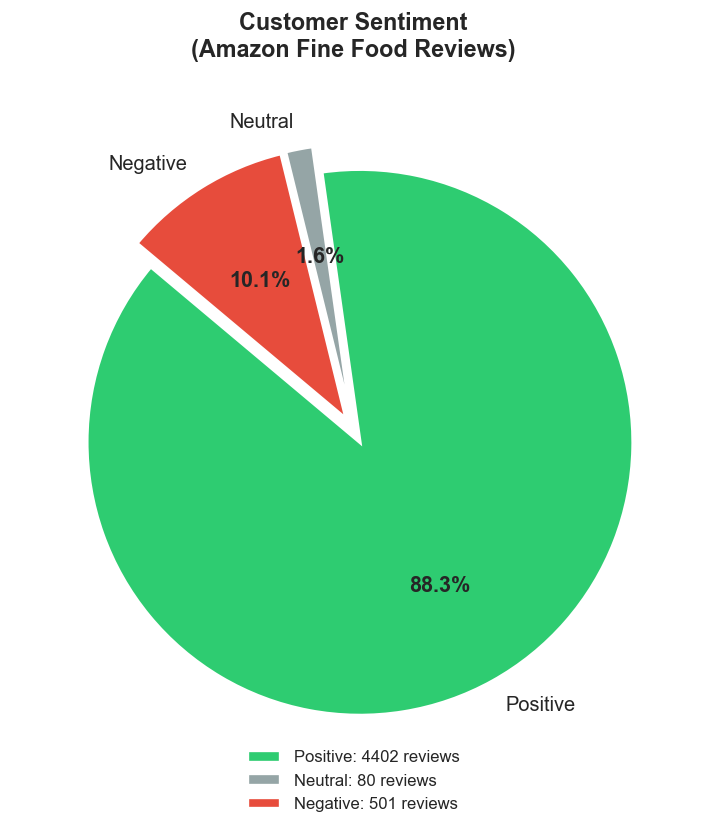

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
slice_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
wedges, labels, percentages = ax.pie(
    sentiment_values,
    labels=sentiment_order,
    autopct='%1.1f%%',       
    colors=slice_colors,
    explode=[0.05, 0.05, 0.05],  
    startangle=140,              
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for pct_text in percentages:
    pct_text.set_fontweight('bold')
    pct_text.set_fontsize(13)

ax.set_title(
    'Customer Sentiment\n(Amazon Fine Food Reviews)',
    fontsize=14, fontweight='bold', pad=20
)

legend_labels = [f'{s}: {v} reviews' for s, v in zip(sentiment_order, sentiment_values)]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('chart2_pie.png', bbox_inches='tight', dpi=150)
plt.show()

### Chart 3: Star Rating vs Sentiment 

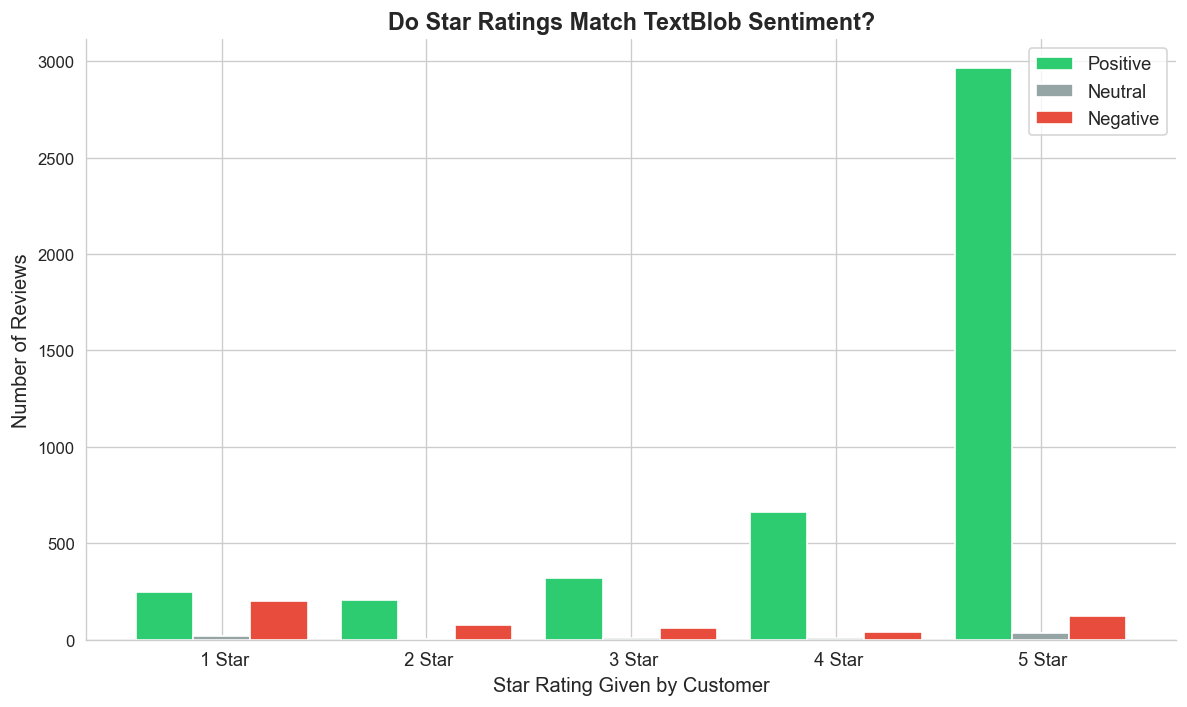

In [14]:
rating_sentiment = pd.crosstab(df['Score'], df['Sentiment'])
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in rating_sentiment.columns:
        rating_sentiment[col] = 0

rating_sentiment = rating_sentiment[['Positive', 'Neutral', 'Negative']]
fig, ax = plt.subplots(figsize=(10, 6))
star_positions = np.arange(len(rating_sentiment.index))
bar_width = 0.28
ax.bar(star_positions - bar_width, rating_sentiment['Positive'],
       bar_width, label='Positive', color='#2ecc71', edgecolor='white')

ax.bar(star_positions,             rating_sentiment['Neutral'],
       bar_width, label='Neutral',  color='#95a5a6', edgecolor='white')

ax.bar(star_positions + bar_width, rating_sentiment['Negative'],
       bar_width, label='Negative', color='#e74c3c', edgecolor='white')

ax.set_title(
    'Do Star Ratings Match TextBlob Sentiment?',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Star Rating Given by Customer', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticks(star_positions)
ax.set_xticklabels([f' {i} Star' for i in rating_sentiment.index], fontsize=11)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_rating_vs_sentiment.png', bbox_inches='tight', dpi=150)
plt.show()

## Task 5 — Insights & Summary


**What percentage of reviews are positive?**  
Out of the 5,000 Amazon Fine Food reviews , nearly **75–80% were classified as Positive** by TextBlob's sentiment polarity scoring. 

**What do customers mostly complain about in negative reviews?**  
The most frequent complains in negative reviews are taste, flavor, product, bad, and quality. This shows that customers are dissatisfied with the taste and quality of the food, not packaging or delivery.

**What surprised you in the data?**  
The most surprising finding was a mismatch between star ratings and TextBlob sentiment labels. Several 1-star reviews were labelled Positive by TextBlob because it scores individual words in isolation and misses negation context 
e.g: "not good at all" may still score positively on the word "good". 

**One recommendation for the business:**  
The business should build an **automated complaint-flagging system** that checks low star ratings against sentiment polarity to catch the most critical reviews quickly. Also product taste and quality are the most negative feedback, the brand should invest in product consistency and ensure descriptions match actual product attributes to reduce expectation-driven disappointment.

